# Modelo para reconocimiento de prendas

In [38]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [39]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

Tenemos 60000 imagenes de 28x28

In [40]:
train_images.shape

(60000, 28, 28)

In [41]:
len(train_images)

60000

In [42]:
test_images.shape

(10000, 28, 28)

In [43]:
np.unique(train_labels)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [44]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [45]:
print("Elemento 125", train_labels[125])

Elemento 125 2


In [46]:
class_names[2]

'Pullover'

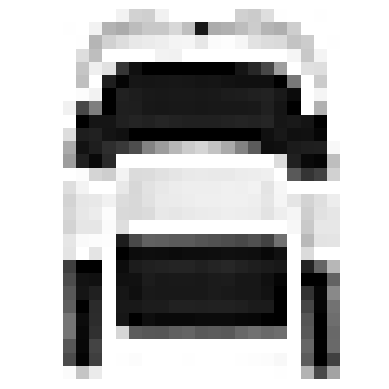

In [47]:
plt.imshow(train_images[125], cmap="binary")
plt.axis("off")
plt.show()

In [48]:
print("Valor máximo", max(train_images[125].reshape(784)))
print("Valor mínimo", min(train_images[125].reshape(784)))
print("Imagen 125", train_images[125])

Valor máximo 255
Valor mínimo 0
Imagen 125 [[  0   0   0   0   0   0   0   0  13  45  48  14   0   0   0   0   0  47
   52  33   1   0   0   1   0   0   0   0]
 [  0   0   0   0   1   0  13  75  84  67  55  55  39  64 230  83  79  66
   51  74  80  49   0   0   0   0   0   0]
 [  0   0   0   0   0   1  74  46  34  23  20  17  11  10  24   4   2   9
   29  35  37  60  51   0   1   0   0   0]
 [  0   0   0   0   0  34  65   0   0   0   0  13  14   0   0   0   0   0
    0   0   0  10  55  11   0   0   0   0]
 [  0   0   0   0   0  58  16  30 202 239 255 255 255 255 255 255 254 234
  216 184  97   0  31  33   0   0   0   0]
 [  0   0   0   0   0  64   0 225 251 233 234 233 232 233 235 234 236 238
  238 239 254 135   0  52   0   0   0   0]
 [  0   0   0   0   0   3  13 255 221 226 229 230 229 229 230 229 227 226
  223 220 229 244   0  10   0   0   0   0]
 [  0   0   0   0  14 184 128 255 224 225 230 232 231 231 232 230 231 230
  229 222 234 255   0  78   0   0   0   0]
 [  0   0   0   0   0

In [49]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [50]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(512, activation='relu', kernel_initializer='he_uniform'),
    tf.keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [51]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_images, train_labels, batch_size=64, epochs=10)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7851 - loss: 0.6194
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8695 - loss: 0.3634
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8798 - loss: 0.3301
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8912 - loss: 0.2975
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8975 - loss: 0.2783
Epoch 6/10


In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

In [ ]:
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

In [ ]:
predictions = np.round(model.predict(test_images), 2)

In [ ]:
predictions

In [ ]:
print(predictions[98])
print(np.argmax(predictions[98]))
print(test_labels[98])

print(class_names[4])

plt.imshow(test_images[98], cmap="binary")
plt.axis("off")
plt.show()

In [ ]:
print(predictions[22])
print(np.argmax(predictions[22]))
print(test_labels[22])

print(class_names[7])

plt.imshow(test_images[22], cmap="binary")
plt.axis("off")
plt.show()

In [ ]:
model.save("zalando.keras")